<a href="https://colab.research.google.com/github/malikshahzaib263/neurofive-ml-track/blob/main/Week_2_Task_4_House_Price_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 - Machine Learning Fundamentals

# Task 4: House Price Prediction with Linear Regression

### Neurofive Solutions – Machine Learning Track

**Author:** Shahzaib Arshad

---

## Project Overview

The objective of this project is to build a Linear Regression model that predicts house prices using the California Housing dataset. I selected important numerical features that may influence house prices, divided the dataset into training and testing sets, trained the model, and evaluated its performance using RMSE and R² score. Finally, I compared actual and predicted prices using a scatter plot.

## Project Objectives

The main objectives of this project are:

- Load and inspect a housing dataset.
- Select important features that may affect house prices.
- Split the data into training and testing sets.
- Train a Linear Regression model.
- Evaluate the model using RMSE and R² score.
- Compare actual and predicted prices visually.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Load the California Housing Dataset

The California Housing dataset is loaded directly from scikit-learn. It contains information about housing districts in California, including income, average house age, number of rooms, population, and median house value.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [4]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


## Feature Selection

I selected five features that may have a strong influence on house prices:

- MedInc: Median income of households
- HouseAge: Median age of houses
- AveRooms: Average number of rooms
- AveBedrms: Average number of bedrooms
- Latitude: Geographic location of the district

The target variable is MedHouseVal, which represents the median house value.

In [8]:
features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Latitude"
]

X = df[features]
y = df["MedHouseVal"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20640, 5)
Target shape: (20640,)


In [9]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Latitude
0,8.3252,41.0,6.984127,1.023810,37.88
1,8.3014,21.0,6.238137,0.971880,37.86
2,7.2574,52.0,8.288136,1.073446,37.85
3,5.6431,52.0,5.817352,1.073059,37.85
4,3.8462,52.0,6.281853,1.081081,37.85


## Train-Test Split

The dataset is divided into 80% training data and 20% testing data. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (16512, 5)
Testing data shape: (4128, 5)


## Train the Linear Regression Model

Linear Regression is used to predict a continuous numerical value. In this project, the model learns the relationship between the selected housing features and the median house price.

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## Make Predictions

The trained model is used to predict house prices for the testing dataset.

In [12]:
y_pred = model.predict(X_test)

print("First 10 predicted prices:")
print(y_pred[:10])

First 10 predicted prices:
[1.00536619 1.57241029 2.56795421 2.68740901 1.96130774 2.20873256
 2.72361364 2.22385451 2.36565696 4.25656137]


In [13]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

results.head(10)

,Actual Price,Predicted Price
0,0.47700,1.005366
1,0.45800,1.572410
2,5.00001,2.567954
3,2.18600,2.687409
4,2.78000,1.961308
5,1.58700,2.208733
6,1.98200,2.723614
7,1.57500,2.223855
8,3.40000,2.365657
9,4.46600,4.256561


## Model Evaluation

The model is evaluated using:

- RMSE: Shows the average prediction error in the same unit as the target value.
- R² Score: Shows how much variation in house prices is explained by the model.

In [14]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 0.7989
R² Score: 0.5129


## R² Score Explanation

The R² score shows how much of the variation in house prices is explained by the model. For example, an R² score of 0.60 means that the selected features explain approximately 60% of the differences in house prices. The remaining variation may be caused by other factors such as location quality, nearby facilities, property condition, and market trends. A higher R² score generally means the model explains the data better.

## Predicted vs Actual House Prices

The scatter plot compares the actual house prices with the prices predicted by the model. Points closer to the diagonal reference line indicate more accurate predictions.

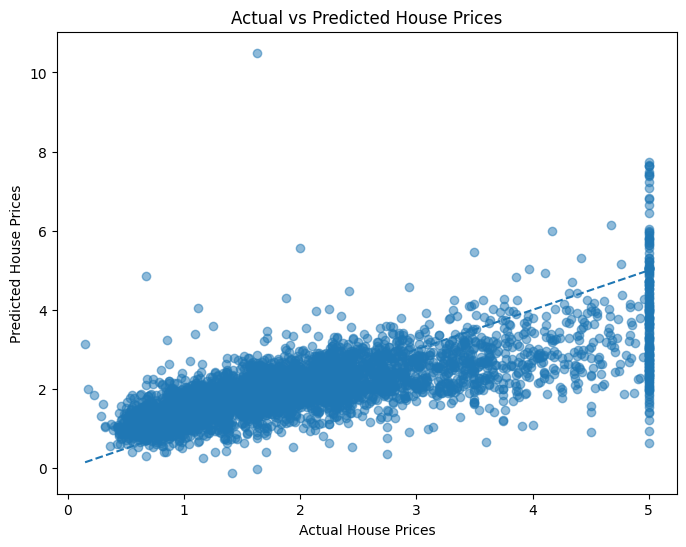

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.show()

## Conclusion

In this project, I trained a Linear Regression model to predict house prices using five selected features from the California Housing dataset. The model was evaluated using RMSE and R² score. The predicted-versus-actual scatter plot showed how closely the predictions matched the real house prices. The model provides a useful baseline, although its performance could be improved by using more features, feature engineering, or more advanced regression algorithms.